<a href="https://colab.research.google.com/github/JorgeRf07/Diplomado-Redes-Neuronales-Artificiales/blob/main/Practica_2_(Preguntas)Ajuste_Funciones_Redes_Neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importar las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

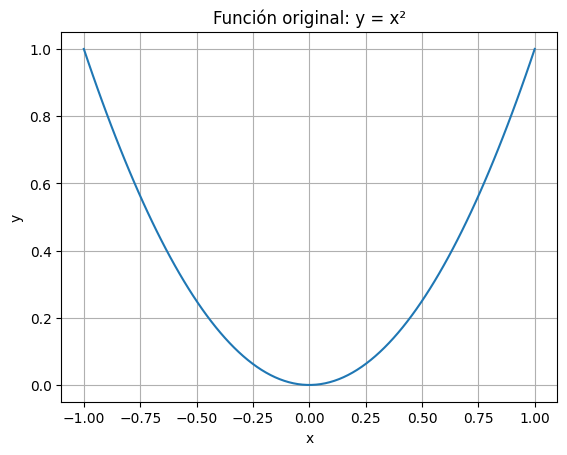

Época: 0 Error: 0.29561761113912915
Época: 500 Error: 0.0037977162963871154
Época: 1000 Error: 0.0021702139000419553
Época: 1500 Error: 0.0016410399647943266
Época: 2000 Error: 0.001291959111858604
Época: 2500 Error: 0.001047318643377432
Época: 3000 Error: 0.0008673271786981473
Época: 3500 Error: 0.0007299795811882236
Época: 4000 Error: 0.0006222753914814865
Época: 4500 Error: 0.0005360422711166834

Predicciones finales:



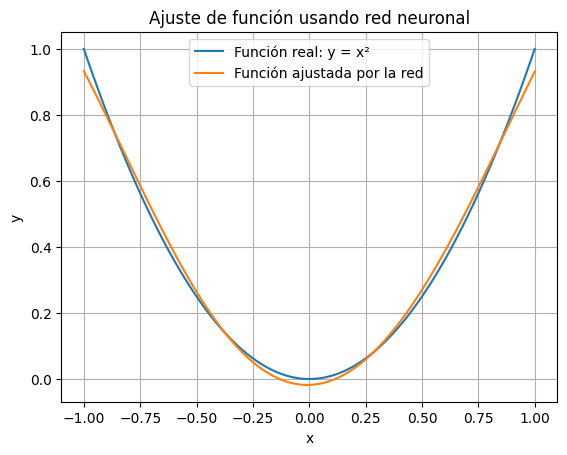

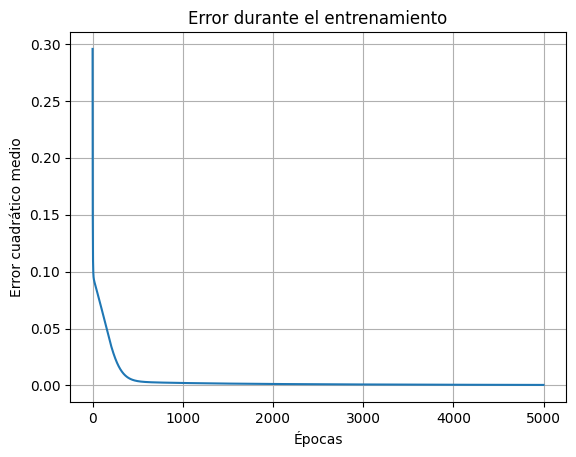

[[-0.8]
 [-0.5]
 [ 0. ]
 [ 0.5]
 [ 0.8]]
Entrada: -0.8
Predicción de la red: 0.6562298342693462
Valor real: 0.6400000000000001
-------------------------
Entrada: -0.5
Predicción de la red: 0.26426017062338863
Valor real: 0.25
-------------------------
Entrada: 0.0
Predicción de la red: -0.017842018895344536
Valor real: 0.0
-------------------------
Entrada: 0.5
Predicción de la red: 0.27024827379016486
Valor real: 0.25
-------------------------
Entrada: 0.8
Predicción de la red: 0.6508814822086415
Valor real: 0.6400000000000001
-------------------------


In [62]:
#Definir la función matemática a ajustar
#En esta práctica se utilizará la siguiente función cuadrática: y = x²
#Esta función recibe un valor de entrada x y devuelve como salida el
#cuadrado de ese valor.

X = np.linspace(-1, 1, 100).reshape(-1, 1)
y = X ** 2

# Visualizar la función original
plt.plot(X, y)
plt.title("Función original: y = x²")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

#Definir la función de activación
#La función tangente hiperbólica permite que la red neuronal aprenda
#relaciones no lineales.

def tanh(x):
  return np.tanh(x)

#También se requiere la derivada de la función tangente hiperbólica,
#ya que será utilizada durante la retropropagación del error.

def derivada_tanh(x):
  return 1 - np.tanh(x) ** 2

#Inicializar los parámetros de la red neuronal
#La red neuronal necesita pesos y sesgos para poder aprender.
#Estos valores se inicializan de manera aleatoria.

np.random.seed(42)
neuronas_entrada = 1
neuronas_ocultas = 5
neuronas_salida = 1
W1 = np.random.randn(neuronas_entrada, neuronas_ocultas)
b1 = np.zeros((1, neuronas_ocultas))
W2 = np.random.randn(neuronas_ocultas, neuronas_salida)
b2 = np.zeros((1, neuronas_salida))

#La propagación hacia adelante consiste en pasar los datos por
#la red neuronal para obtener una predicción.

#Primero se calcula la salida de la capa oculta:

#Z1 = X, W1 + b1
#A1 = tanh(Z1)

#Después se calcula la salida final de la red:

#Z2 = A1, W2 + b2

#Crear la función de propagación hacia adelante
#Esta función recibe los datos de entrada, los pesos y los sesgos.
#Después calcula la salida de la capa oculta y la predicción final.

def propagacion_adelante(X, W1, b1, W2, b2):
  Z1 = np.dot(X, W1) + b1
  A1 = tanh(Z1)
  Z2 = np.dot(A1, W2) + b2
  return Z1, A1, Z2

#Definir la función de error
#La fórmula del error cuadrático medio es:

#ECM = promedio((y_real - y_predicha)²)

def calcular_error(y_real, y_predicha):
    return np.mean((y_real - y_predicha) ** 2)

#La retropropagación permite calcular cuánto deben ajustarse los pesos y sesgos
#para reducir el error.

#Primero se calcula el error en la salida:
#error_salida = y_predicha - y_real

#Después se calcula el ajuste necesario en los pesos de la capa de salida
#y en los pesos de la capa oculta.
#La actualización de parámetros se realiza usando una tasa de aprendizaje:

#parametro_nuevo = parametro_actual - tasa_aprendizaje * gradiente

#La tasa de aprendizaje controla qué tan grandes serán los cambios en los
#pesos y sesgos.

#Crear la función de entrenamiento

#Esta función realiza el entrenamiento completo de la red neuronal.
#En cada época, la red calcula una predicción, mide el error,
#obtiene los ajustes necesarios y actualiza sus parámetros.

def entrenar_red(X, y, W1, b1, W2, b2, tasa_aprendizaje, epocas):
    errores = []
    n = len(X)

    for epoca in range(epocas):
        Z1, A1, y_predicha = propagacion_adelante(X, W1, b1, W2, b2)

        error = calcular_error(y, y_predicha)
        errores.append(error)

        dZ2 = (y_predicha - y)
        dW2 = np.dot(A1.T, dZ2) / n
        db2 = np.sum(dZ2, axis=0, keepdims=True) / n

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * derivada_tanh(Z1)
        dW1 = np.dot(X.T, dZ1) / n
        db1 = np.sum(dZ1, axis=0, keepdims=True) / n

        W2 = W2 - tasa_aprendizaje * dW2
        b2 = b2 - tasa_aprendizaje * db2
        W1 = W1 - tasa_aprendizaje * dW1
        b1 = b1 - tasa_aprendizaje * db1

        if epoca % 500 == 0:
            print("Época:", epoca, "Error:", error)

    return W1, b1, W2, b2, errores

#Entrenar la red neuronal
#Define la tasa de aprendizaje y el número de épocas:

tasa_aprendizaje = 0.1
epocas = 5000
#Durante este proceso, observa cómo el error disminuye
#conforme avanzan las épocas.
W1, b1, W2, b2, errores = entrenar_red(
    X,
    y,
    W1,
    b1,
    W2,
    b2,
    tasa_aprendizaje,
    epocas
)
#Obtener las predicciones finales
#Después del entrenamiento, se obtienen las predicciones
#finales de la red neuronal:
Z1, A1, y_predicha = propagacion_adelante(X, W1, b1, W2, b2)
print("\nPredicciones finales:\n")

#Graficar la función real y la función ajustada
plt.plot(X, y, label="Función real: y = x²")
plt.plot(X, y_predicha, label="Función ajustada por la red")
plt.title("Ajuste de función usando red neuronal")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

#Graficar el error durante el entrenamiento
#Esta gráfica permite observar si la red neuronal
#aprendió correctamente la función.
plt.plot(errores)
plt.title("Error durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Error cuadrático medio")
plt.grid(True)
plt.show()

#Probar la red con nuevos valores
#Prueba la red neuronal con nuevos valores de entrada:
nuevos_valores = np.array([
[-0.8],
[-0.5],
[0.0],
[0.5],
[0.8]
])
print(nuevos_valores)
Z1_nuevo, A1_nuevo, predicciones_nuevas = propagacion_adelante(
nuevos_valores,

W1,
b1,
W2,
b2
)
for i in range(len(nuevos_valores)):
  print("Entrada:", nuevos_valores[i][0])
  print("Predicción de la red:", predicciones_nuevas[i][0])
  print("Valor real:", nuevos_valores[i][0] ** 2)
  print("-------------------------")

////////Preguntgas///////////

¿Qué significa ajustar una función usando una red neuronal?
una red neuronal tiene que aprender el comportamiento de una función matemática a partir de datos generados, tiene que encontrar un modelo capaz de representar de manera aproximada una relación entre datos. Por ejemplo, si se tienen valores de entrada x y sus correspondientes salidas y, una red neuronal puede entrenarse para aprender esa relación y posteriormente estimar nuevos valores.
¿Cuál es la diferencia entre clasificación y ajuste de funciones?
Clasificación como su nombre lo dice clasifica entre verdadero o falso, aprobado o reprobado, etc. Que nos ayude a identificar la categoría de o de los datos y ajuste de funciones no ayuda a encontrar precisamente una función matemática con la cual podamos encontrar o aproximar el resultado.
¿Qué función matemática se utilizó en esta práctica?
y = x²
¿Qué representa la variable X?
Una salida al cuadrado del valor que recibe
¿Qué representa la variable y?
Una entrada.
¿Cuál es la función de los pesos W1 y W2?
Son los pesos de entrada como de salida y los pesos ocultos que requiere la neurona los cuales se inician de manera aleatoria.
¿Cuál es la función de los sesgos b1 y b2?
Son los sesgos de la capa oculta y sesgo de capa de salida
¿Para qué se utiliza la función tangente hiperbólica?
La función tangente hiperbólica permite que la red neuronal aprenda relaciones no lineales.
¿Qué mide el error cuadrático medio?
Mide qué tan lejos está la predicción de la red respecto al valor real
¿Qué ocurre cuando el error disminuye durante el entrenamiento?
Está mejorando sus predicciones


¿Qué representa la gráfica de la función real y la función ajustada?
Calcula una predicción, mide el error, obtiene los ajustes necesarios y actualiza sus pará-metros.
¿La red neuronal logró aproximar correctamente la función?
Si. Porque si el error disminuye durante el entrenamiento, significa que la red está mejorando sus predicciones.
